In [20]:
#imports

import openmeteo_requests

import matplotlib.pyplot as plt
import pandas as pd
import requests_cache
from retry_requests import retry

In [3]:
def getData(lat=52.52, long=13.41, start="2025-10-26", end="2025-11-09", features=["weather_code"]):
    # Setup the Open-Meteo API client with cache and retry on error
    cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
    retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
    openmeteo = openmeteo_requests.Client(session = retry_session)

    # Make sure all required weather variables are listed here
    # The order of variables in hourly or daily is important to assign them correctly below
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
	"latitude": lat,
	"longitude": long,
	"start_date": start,
	"end_date": end,
    "timezone": "America/Denver",
	"daily": features,
	"temperature_unit": "fahrenheit",
	"wind_speed_unit": "mph",
	"precipitation_unit": "inch",
    }
    responses = openmeteo.weather_api(url, params=params)
    return responses

In [4]:
def dataToDataframe(response, features=["weather_code"]):
    daily = response.Daily()

    daily_data = {"date": pd.date_range(
	    start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	    end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	    freq = pd.Timedelta(seconds = daily.Interval()),
	    inclusive = "left"
    )}

    for idx, feat in enumerate(features):
        daily_data[feat] = daily.Variables(idx).ValuesAsNumpy()

    df = pd.DataFrame(data=daily_data)
    return df


In [5]:
#Set Parameters
features = ["weather_code", "temperature_2m_mean", "sunrise", "sunset", "snowfall_sum", "precipitation_sum", "rain_sum", "wind_speed_10m_max"]
lat = 43.373508
long = -112.135382
startDate = "2015-01-01"
endDate = "2025-10-31"

In [6]:
resp = getData(lat=lat, long=long, start=startDate, end=endDate, features=features)
df = dataToDataframe(resp[0], features=features)

In [7]:
df.head()

,date,weather_code,temperature_2m_mean,sunrise,sunset,snowfall_sum,precipitation_sum,rain_sum,wind_speed_10m_max
0,2015-01-01 07:00:00+00:00,2.0,2.064200,0,0,0.000000,0.0,0.0,4.112674
1,2015-01-02 07:00:00+00:00,2.0,4.651699,0,0,0.000000,0.0,0.0,3.355500
2,2015-01-03 07:00:00+00:00,3.0,13.539200,0,0,0.000000,0.0,0.0,3.809474
3,2015-01-04 07:00:00+00:00,71.0,21.871698,0,0,0.137795,0.0,0.0,9.059159
4,2015-01-05 07:00:00+00:00,71.0,34.370449,0,0,0.055118,0.0,0.0,19.544006


In [8]:
#Not it became clear after performed the api call that sunrise/sunse where in fact all zeros shown below. 
#Thus they can be dropped from the dataframe

print(df['sunrise'].value_counts())
print(df['sunset'].value_counts())
df.drop(labels=['sunrise','sunset'], axis=1, inplace=True)

sunrise
0    3957
Name: count, dtype: int64
sunset
0    3957
Name: count, dtype: int64


In [9]:
#Note weather type uses WMO codes for weather type. This dictionary should enable altering the column
wmo_mapping = {
    0: "Clear sky",
    1: "Mainly clear",
    2: "Partly cloudy",
    3: "Overcast",
    45: "Fog",
    48: "Depositing rime fog",
    51: "Light drizzle",
    53: "Moderate drizzle",
    55: "Dense drizzle",
    56: "Light freezing drizzle",
    57: "Dense freezing drizzle",
    61: "Slight rain",
    63: "Moderate rain",
    65: "Heavy rain",
    66: "Light freezing rain",
    67: "Heavy freezing rain",
    71: "Slight snow fall",
    73: "Moderate snow fall",
    75: "Heavy snow fall",
    77: "Snow grains",
    80: "Slight rain showers",
    81: "Moderate rain showers",
    82: "Violent rain showers",
    85: "Slight snow showers",
    86: "Heavy snow showers",
    95: "Thunderstorm",
    96: "Thunderstorm with slight hail",
    99: "Thunderstorm with heavy hail"
}

In [10]:
df['weather_category'] = df['weather_code'].map(wmo_mapping)
id_weather_counts = df['weather_category'].value_counts()
id_weather_counts

weather_category
Overcast              1579
Moderate snow fall     428
Light drizzle          394
Clear sky              321
Slight snow fall       279
Partly cloudy          263
Mainly clear           208
Moderate drizzle       163
Slight rain            119
Heavy snow fall         75
Dense drizzle           74
Moderate rain           54
Name: count, dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   date                 3957 non-null   datetime64[ns, UTC]
 1   weather_code         3957 non-null   float32            
 2   temperature_2m_mean  3957 non-null   float32            
 3   snowfall_sum         3957 non-null   float32            
 4   precipitation_sum    3957 non-null   float32            
 5   rain_sum             3957 non-null   float32            
 6   wind_speed_10m_max   3957 non-null   float32            
 7   weather_category     3957 non-null   object             
dtypes: datetime64[ns, UTC](1), float32(6), object(1)
memory usage: 154.7+ KB


In [12]:
#here I can do the same thing for another area. I don't know what the restrictions
#for api call amounts is but you could easily get a datasets of major cities and their lat-long
#and iterate through to create a very large dataset.

lat = 40.2335
long = 111.6670

resp = getData(lat=lat, long=long, start=startDate, end=endDate, features=features)
df_ut = dataToDataframe(resp[0], features=features)

In [13]:
df_ut.drop(labels=['sunrise','sunset'], axis=1, inplace=True)
df_ut['weather_category'] = df_ut['weather_code'].map(wmo_mapping)

df_ut.head()

,date,weather_code,temperature_2m_mean,snowfall_sum,precipitation_sum,rain_sum,wind_speed_10m_max,weather_category
0,2015-01-01 07:00:00+00:00,1.0,15.677451,0.000000,0.0,0.0,13.798864,Mainly clear
1,2015-01-02 07:00:00+00:00,2.0,23.319948,0.000000,0.0,0.0,9.835170,Partly cloudy
2,2015-01-03 07:00:00+00:00,3.0,22.847450,0.000000,0.0,0.0,8.849589,Overcast
3,2015-01-04 07:00:00+00:00,71.0,28.472450,0.027559,0.0,0.0,14.542220,Slight snow fall
4,2015-01-05 07:00:00+00:00,3.0,15.467450,0.000000,0.0,0.0,13.876615,Overcast


In [14]:
ut_weather_counts = df_ut['weather_category'].value_counts()
ut_weather_counts

weather_category
Overcast              1734
Light drizzle          441
Clear sky              432
Partly cloudy          235
Mainly clear           230
Moderate drizzle       185
Slight rain            185
Moderate rain          170
Slight snow fall       128
Moderate snow fall      96
Dense drizzle           74
Heavy rain              25
Heavy snow fall         22
Name: count, dtype: int64

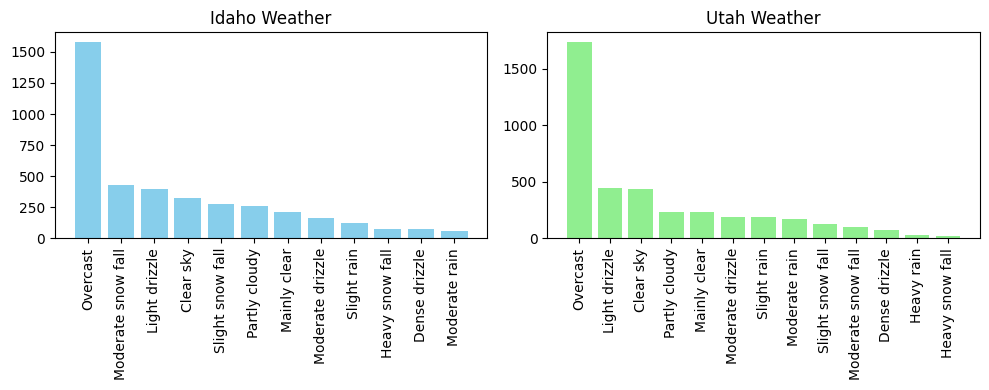

In [33]:
#Generate images of weather_category
fig, ax = plt.subplots(1,2,figsize=(10,4))

ax[0].bar(id_weather_counts.index, id_weather_counts, color='skyblue')
ax[0].set_title('Idaho Weather')
ax[0].tick_params(axis='x', rotation=90)

ax[1].bar(ut_weather_counts.index, ut_weather_counts, color='lightgreen')
ax[1].set_title('Utah Weather')
ax[1].tick_params(axis='x', rotation=90)

plt.tight_layout()  # Adjust spacing
plt.savefig('bar.png', dpi=300)
plt.show()




In [35]:
print(f'Idaho temp mean {df['temperature_2m_mean'].mean()}')
print(f'Utah temp mean {df_ut['temperature_2m_mean'].mean()}')

Idaho temp mean 48.54609680175781
Utah temp mean 46.699947357177734


In [23]:
#To csv
df.to_csv("id_Dataset.csv")
df_ut.to_csv("ut_Dataset.csv")